<center>
    <h1 style="font-size: 30px; background-color: #42a5f6;"><b>UNIVERSITE PAUL SABATIER - ENAC </b></h1>
</center>

<br><br>
<center>
    <h1 style="font-size: 24px;"><b>Filière: Master 2 RECHERCHE OPERATIONNELLE ET OPTIMISATION  </b></h1>
</center>
 <br><br>
<center>
    <hr style="height: 4px; background-color: #42a5f;">
    <br>
    <br>
        <h1 style="font-size: 24px;"><b> ALGORITHMES EN APPRENTISSAGE ARTIFICIEL</b></h1>
        <h2 style="font-size: 24px;"><b>  </b></h2>
    <br><br>
    <hr style="height: 5px; background-color: #42a5f;">
</center>

### <center> <b> Auteurs </b> : AHMED KANDJI(UT), ABBE KOKOU XOLAGNA GEROME(UT), Cyrille AKAKPO DE ZOLOU(UT) <center>
<center>
     <br><br>
    <h3><strong>ANNÉE ACADÉMIQUE : 2025-2026</strong></h3>
</center>
<br><br>

## 1. Cadrage du problème : type de tâche et hypothèses

Nous travaillons sur le **PhiUSIIL Phishing URL Dataset** (UCI Machine Learning Repository,
Prasad & Chandra, 2024), qui regroupe 235 795 URLs annotées.

**Attention à la convention d'annotation du jeu de données.** Dans le fichier source :
- `label = 1` : URL **légitime** ;
- `label = 0` : URL de **phishing**.

C'est l'inverse de la convention intuitive, où la classe positive désigne l'événement
que l'on cherche à détecter. Comme la classe d'intérêt métier est ici le phishing,
nous **ré-encodons explicitement la cible** (section 1.bis) pour que :
- `label = 1` : URL de **phishing** ;
- `label = 0` : URL **légitime**.

Chaque échantillon est donc :
- une **entrée** : un ensemble de caractéristiques dérivées de l'URL et du code source de
  la page (longueurs, compteurs HTML, scores, etc.) ;
- une **cible** : la variable `label` ré-encodée.

 Il s'agit d'un problème de **Machine Learning supervisé**.
La cible étant binaire, nous sommes plus précisément dans un cas de **classification**
(catégorie à prédire) **supervisée** (label connu) **binaire** (deux classes).

**Hypothèses implicites :**
- les URLs de phishing présentent des caractéristiques différentes des URLs légitimes ;
- les features fournies contiennent assez d'information pour apprendre cette distinction ;
- les labels sont fiables (peu d'erreurs d'annotation) ;
- le dataset est supposé représentatif d'un contexte d'usage (ce point sera justement
  discuté dans la section *Limites*).


Cette cellule nous permettra de préparer l’environnement, d'importer les librairies utiles et de charger notre dataset.  
Elle est très importante, car la bonne exécution des cellules de code du reste du notebook dépend de cette étape.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

plt.rcParams['figure.figsize'] = (7,4)
sns.set_theme(style='whitegrid')

# Le CSV est cherché dans le dossier du notebook, puis dans le dossier parent.
# Télécharger le fichier depuis :
# https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+dataset
from pathlib import Path

CSV_NAME = 'PhiUSIIL_Phishing_URL_Dataset.csv'
for candidate in [CSV_NAME, Path('..') / CSV_NAME]:
    if Path(candidate).exists():
        DATA_PATH = candidate
        break
else:
    raise FileNotFoundError(
        f"{CSV_NAME} introuvable. Placez le fichier a cote du notebook."
    )

df = pd.read_csv(DATA_PATH)
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


## 1.bis Vérification et ré-encodage de la cible

Avant toute analyse, nous vérifions la convention d'annotation sur des exemples concrets,
puis nous ré-encodons la cible.

Cette étape n'est pas cosmétique : toute l'interprétation métier en dépend. Une lecture
inversée du label conduirait à conclure, par exemple, que les sites de phishing utilisent
systématiquement HTTPS et affichent des mentions de copyright.


In [2]:
# --- Vérification de la convention d'annotation du fichier source ---
print("Convention du fichier source (documentation UCI) : 1 = legitimate, 0 = phishing")
print("\nExemples annotés 1 dans le fichier source :")
print(df[df['label'] == 1]['URL'].head(5).to_string(index=False))
print("\nExemples annotés 0 dans le fichier source :")
print(df[df['label'] == 0]['URL'].head(5).to_string(index=False))

# --- Ré-encodage : la classe positive devient le phishing ---
df['label'] = 1 - df['label']

print("\nAprès ré-encodage (0 = légitime, 1 = phishing) :")
print(df['label'].value_counts().sort_index())


Convention du fichier source (documentation UCI) : 1 = legitimate, 0 = phishing

Exemples annotés 1 dans le fichier source :
  https://www.southbankmosaics.com
          https://www.uni-mainz.de
    https://www.voicefmradio.co.uk
       https://www.sfnmjournal.com
https://www.rewildingargentina.org

Exemples annotés 0 dans le fichier source :
               http://www.teramill.com
           http://www.f0519141.xsph.ru
              http://www.shprakserf.gq
https://service-mitld.firebaseapp.com/
     http://www.kuradox92.lima-city.de

Après ré-encodage (0 = légitime, 1 = phishing) :
label
0    134850
1    100945
Name: count, dtype: int64


## 2. Exploration des données (EDA)
Avant de choisir des modèles, nous commençons par comprendre les données :
- dimensions du dataset,
- types de colonnes,
- présence de valeurs manquantes(déja informé sur le site),
- distribution de la cible,
- quelques exemples d'URLs légitimes / phishing.

Ici, on veut examiner la structure de notre jeu de données à savoir : les dimensions, les types de colonnes,quelques aperçu des premières valeurs et présence éventuelle de données manquantes.  
Il s’agit d’une étape essentielle pour vérifier la qualité des données avant de poursuivre l’analyse.


In [3]:
# Dimensions et types des colonnes
print('Shape du dataset :', df.shape)
print('\nTypes des colonnes :')
print(df.dtypes.value_counts())

print('\nAperçu des premières colonnes :')
print(df.dtypes.head())

# Vérification de valeurs manquantes
print('\nNombre de valeurs manquantes par colonne :')
print(df.isna().sum().sort_values(ascending=False))

Shape du dataset : (235795, 56)

Types des colonnes :
int64      41
float64    10
str         5
Name: count, dtype: int64

Aperçu des premières colonnes :
FILENAME          str
URL               str
URLLength       int64
Domain            str
DomainLength    int64
dtype: object

Nombre de valeurs manquantes par colonne :
FILENAME                      0
URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQ

Cette cellule, analyse la distribution de la variable cible (0 = légitime, 1 = phishing).  
Elle est importante car un dataset équilibré ou déséquilibré n’impose pas les mêmes précautions :  
– un dataset équilibré simplifie l’entraînement ;  
– un dataset déséquilibré nécessiterait du rééchantillonnage ou des métriques (moyens d'évaluation d'un modèle) adaptées.


Distribution de la cible (0 = légitime, 1 = phishing) :
label
0    134850
1    100945
Name: count, dtype: int64


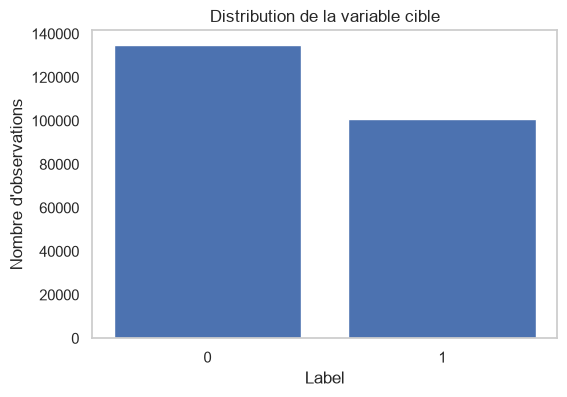

In [4]:
# Distribution de la variable cible
label_counts = df['label'].value_counts().sort_index()
print('Distribution de la cible (0 = légitime, 1 = phishing) :')
print(label_counts)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(label_counts.index.astype(str), label_counts.values)
ax.set_xlabel('Label')
ax.set_ylabel("Nombre d'observations")
ax.set_title('Distribution de la variable cible')
ax.grid(False)
plt.show()

# Commentaire : le dataset est relativement équilibré entre 0 et 1,
# ce qui simplifie l'entraînement de modèles de classification.

In [5]:
# Quelques exemples d'URL légitimes et de phishing
print('Quelques URLs légitimes (label = 0) :')
print(df[df['label'] == 0][['URL', 'Domain', 'TLD']].head(5))

print('\nQuelques URLs de phishing (label = 1) :')
print(df[df['label'] == 1][['URL', 'Domain', 'TLD']].head(5))

Quelques URLs légitimes (label = 0) :
                                  URL                      Domain  TLD
0    https://www.southbankmosaics.com    www.southbankmosaics.com  com
1            https://www.uni-mainz.de            www.uni-mainz.de   de
2      https://www.voicefmradio.co.uk      www.voicefmradio.co.uk   uk
3         https://www.sfnmjournal.com         www.sfnmjournal.com  com
4  https://www.rewildingargentina.org  www.rewildingargentina.org  org

Quelques URLs de phishing (label = 1) :
                                       URL                         Domain  TLD
11                 http://www.teramill.com               www.teramill.com  com
20             http://www.f0519141.xsph.ru           www.f0519141.xsph.ru   ru
21                http://www.shprakserf.gq              www.shprakserf.gq   gq
27  https://service-mitld.firebaseapp.com/  service-mitld.firebaseapp.com  com
28       http://www.kuradox92.lima-city.de     www.kuradox92.lima-city.de   de


Ces exemples donnent une **intuition humaine** :
- peut‑on, à la main, distinguer certaines URLs de phishing ?
- observe‑t‑on des motifs récurrents (longueur, structure du domaine, TLD, etc.) ?

Cette intuition va guider le **feature engineering** et le choix de modèles.

## 3. Typologie des features

Nous distinguons plusieurs types de variables :
- **Textuelles** : `URL`, `Domain` (chaînes complètes)
- **Catégorielle** : `TLD`
- **Numériques** : longueurs, scores, compteurs (ex : `URLLength`, `DomainLength`, `NoOfImage`, ...)
- **Binaires** : indicateurs 0/1 (ex : `IsDomainIP`, `HasObfuscation`, `IsHTTPS`, ...)
- **Identifiant** : `FILENAME` (non informatif pour la prédiction)

Objectif : représenter ces features de façon adaptée pour des modèles tabulaires.

On veut connaitre la nature de nos différentes variable, car chaque type de variable doit être traité différemment dans la suite du notebook.

In [6]:
# Typologie des colonnes
all_cols = df.columns.tolist()
print('Colonnes du dataset :')
print(all_cols)

text_cols = ['URL', 'Domain']
cat_cols = ['TLD']
id_cols = ['FILENAME']

binary_cols = []
numeric_cols = []

for col in df.columns:
    if col in text_cols + cat_cols + id_cols + ['label']:
        continue
    unique_vals = set(df[col].dropna().unique())
    if unique_vals.issubset({0, 1}):
        binary_cols.append(col)
    else:
        numeric_cols.append(col)

print('\nColonnes textuelles :', text_cols)
print('Colonnes catégorielles :', cat_cols)
print('Colonnes identifiants :', id_cols)
print('Colonnes binaires (détectées) :', binary_cols[:10], '...')
print('Colonnes numériques :', numeric_cols[:10], '...')

Colonnes du dataset :
['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']

Colonnes textuelles : ['URL', 'Domain']
Colonnes catégorie

## 4. Feature engineering

Pour aller au‑delà des features fournies, nous ajoutons trois variables simples mais interprétables :
- `subdomain_count` : nombre de sous-domaines dans `Domain` ;
- `url_domain_length_ratio` : ratio `URLLength / DomainLength` ;
- `domain_digit_ratio` : proportion de chiffres dans le `Domain`.

Ces features sont motivées par l'idée que les URLs de phishing peuvent utiliser :
- des domaines plus complexes avec plusieurs sous-domaines,
- beaucoup de chiffres ou de segments artificiels,
- des URLs longues par rapport au domaine.

Cette cellule crée des features à partir des URLs pour repérer des patterns (des formes ou comportements qui se répètent), comme des URLs très longues ou contenant beaucoup de symboles, afin d’aider le modèle à mieux distinguer phishing et légitime.
Par exemple : si une URL contient beaucoup de “-” ou de “.”, c’est un pattern souvent associé au phishing.

In [7]:
df_fe = df.copy()

# 1) Nombre de sous-domaines
def count_subdomains(domain: str) -> int:
    if not isinstance(domain, str):
        return 0
    return max(domain.count('.') - 1, 0)

df_fe['subdomain_count'] = df_fe['Domain'].apply(count_subdomains)

# 2) Ratio longueur URL / longueur domaine
df_fe['url_domain_length_ratio'] = df_fe['URLLength'] / (df_fe['DomainLength'] + 1e-6)

# 3) Ratio de chiffres dans le domaine
def digit_ratio(s: str) -> float:
    if not isinstance(s, str) or len(s) == 0:
        return 0.0
    digits = sum(c.isdigit() for c in s)
    return digits / len(s)

df_fe['domain_digit_ratio'] = df_fe['Domain'].apply(digit_ratio)

df_fe[['subdomain_count', 'url_domain_length_ratio', 'domain_digit_ratio']].describe()

,subdomain_count,url_domain_length_ratio,domain_digit_ratio
count,235795.000000,235795.000000,235795.000000
mean,1.164758,1.740829,0.031070
std,0.600969,2.349464,0.091962
min,0.000000,1.060000,0.000000
25%,1.000000,1.304348,0.000000
50%,1.000000,1.368421,0.000000
75%,1.000000,1.466667,0.000000
max,10.000000,290.333320,0.885714


### Visualisation de quelques features clés

Nous examinons la distribution de certaines features pour les deux classes :
- `URLLength` (tronquée pour éviter les valeurs extrêmes),
- `DomainLength`,
- `subdomain_count`.

Ici, on veut observer comment certaines caractéristiques simples (longueur de l’URL, longueur du domaine, nombre de sous-domaines) se répartissent entre les deux classes, afin d’observer d’éventuelles différences entre URLs légitimes et phishing.


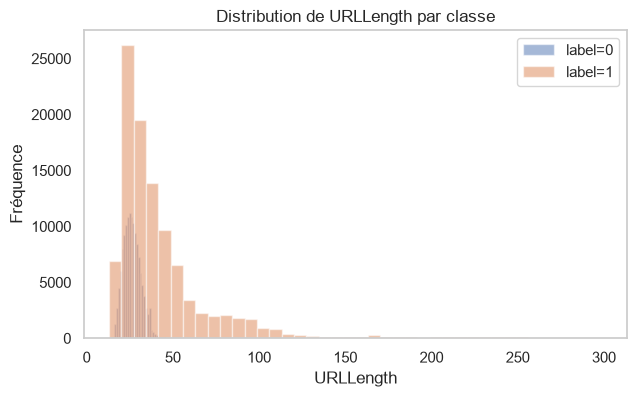

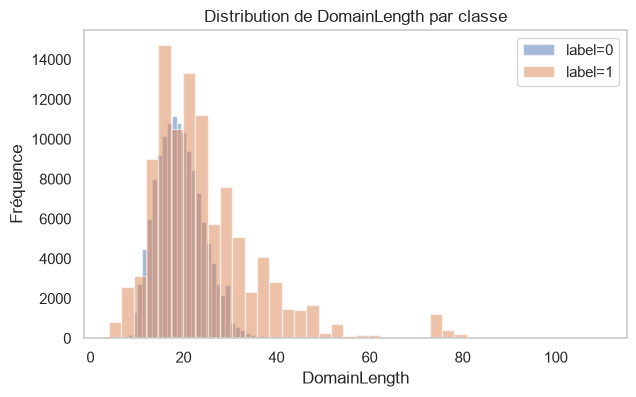

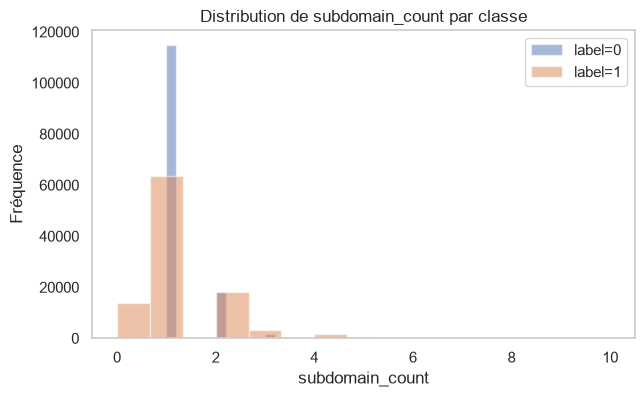

In [8]:
def plot_feature_by_label(df_, feature, bins=40):
    fig, ax = plt.subplots()
    for label_value in [0, 1]:
        subset = df_[df_['label'] == label_value][feature]
        ax.hist(subset, bins=bins, alpha=0.5, label=f'label={label_value}')
    ax.set_title(f'Distribution de {feature} par classe')
    ax.set_xlabel(feature)
    ax.set_ylabel('Fréquence')
    ax.legend()
    ax.grid(False)
    plt.show()

# On tronque URLLength à 300 pour une meilleure lisibilité
plot_feature_by_label(df_fe[df_fe['URLLength'] < 300], 'URLLength')
plot_feature_by_label(df_fe, 'DomainLength')
plot_feature_by_label(df_fe, 'subdomain_count', bins=15)

## 5. Corrélations avec le label et features "expertes"

Nous analysons maintenant la corrélation des variables numériques avec la cible `label`.

On veut calculer ici la corrélation entre chaque variable numérique et la cible (label), afin d’identifier quelles features sont les plus liées au fait qu’une URL soit phishing ou légitime. Cela permet de repérer rapidement les variables qui pourraient être les plus utiles pour les modèles.

In [9]:
# Corrélations avec le label
numeric_df = df_fe.select_dtypes(include=[np.number])

corr = numeric_df.corr()['label'].sort_values(ascending=False)
corr = corr.drop('label')

# On ne garde que les corrélations fortes
strong_corr = corr[abs(corr) > 0.5]

strong_corr_df = pd.DataFrame({
    'Feature': strong_corr.index,
    'Corrélation avec label': strong_corr.values.round(2)
})

strong_corr_df

,Feature,Corrélation avec label
0,SpacialCharRatioInURL,0.53
1,HasHiddenFields,-0.51
2,URLTitleMatchScore,-0.54
3,IsResponsive,-0.55
4,HasSubmitButton,-0.58
5,DomainTitleMatchScore,-0.58
6,IsHTTPS,-0.61
7,HasDescription,-0.69
8,HasCopyrightInfo,-0.74
9,HasSocialNet,-0.78


On observe notamment des corrélations très élevées pour :
- `URLSimilarityIndex`,
- `HasSocialNet`,
- `HasCopyrightInfo`,
- `HasDescription`,
- `IsHTTPS`, etc.

Ces features sont des **indicateurs experts(des signaux construits à partir de connaissances en cybersécurité (ex : HTTPS, copyright, réseaux sociaux) et qui sont connus pour aider à détecter le phishing.)**, directement liés à la sécurité ou à la structure de la page.

 A travers cette cellule , on veut vérifier si ces indicateurs discriminent presque parfaitement nos classes.

C:\Users\EL-GANVIANO\AppData\Local\Temp\ipykernel_24652\2579561646.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_fe, x=feature, hue='label', fill=True,


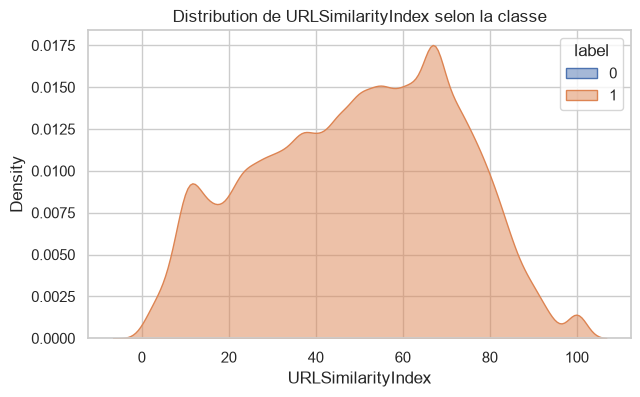

→ Moyenne URLSimilarityIndex pour légitime (0) : 100.000
→ Moyenne URLSimilarityIndex pour phishing (1) : 49.617
------------------------------------------------------------


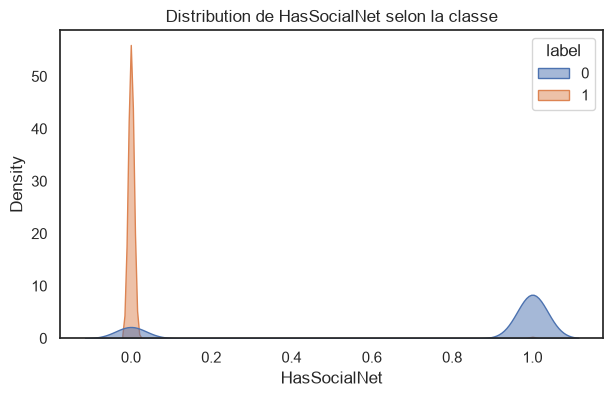

→ Moyenne HasSocialNet pour légitime (0) : 0.795
→ Moyenne HasSocialNet pour phishing (1) : 0.005
------------------------------------------------------------


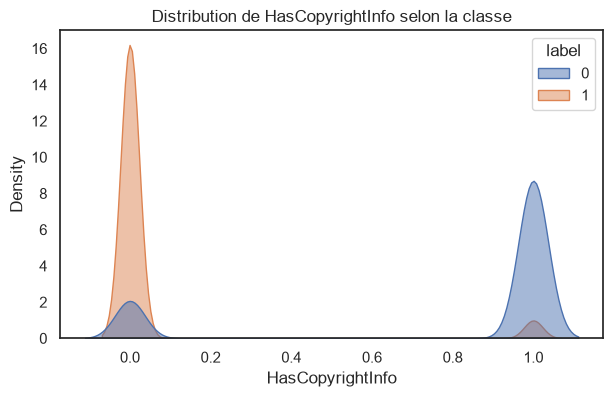

→ Moyenne HasCopyrightInfo pour légitime (0) : 0.808
→ Moyenne HasCopyrightInfo pour phishing (1) : 0.057
------------------------------------------------------------


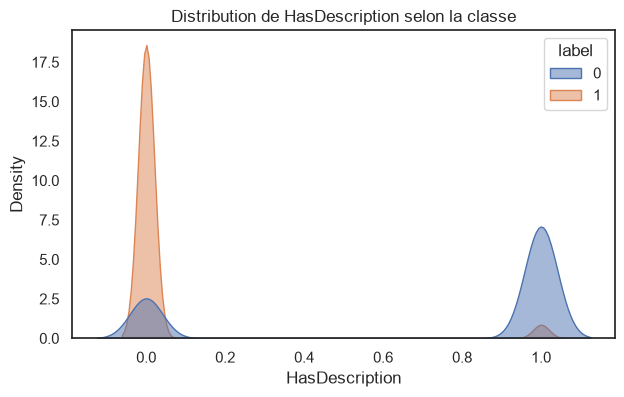

→ Moyenne HasDescription pour légitime (0) : 0.737
→ Moyenne HasDescription pour phishing (1) : 0.044
------------------------------------------------------------


C:\Users\EL-GANVIANO\AppData\Local\Temp\ipykernel_24652\2579561646.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_fe, x=feature, hue='label', fill=True,


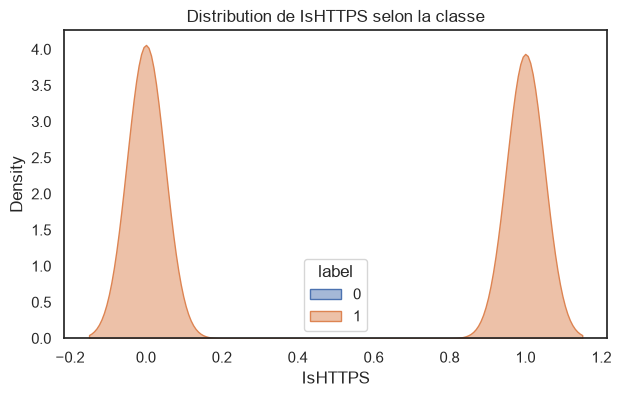

→ Moyenne IsHTTPS pour légitime (0) : 1.000
→ Moyenne IsHTTPS pour phishing (1) : 0.492
------------------------------------------------------------


In [10]:
# Visualisation détaillée de quelques features très corrélées
strong_features = [
    'URLSimilarityIndex',
    'HasSocialNet',
    'HasCopyrightInfo',
    'HasDescription',
    'IsHTTPS'
]

for feature in strong_features:
    plt.figure(figsize=(7,4))
    sns.kdeplot(data=df_fe, x=feature, hue='label', fill=True,
                common_norm=False, alpha=0.5)
    plt.title(f'Distribution de {feature} selon la classe')
    plt.show()

    mean_0 = df_fe[df_fe['label'] == 0][feature].mean()
    mean_1 = df_fe[df_fe['label'] == 1][feature].mean()
    print(f'→ Moyenne {feature} pour légitime (0) : {mean_0:.3f}')
    print(f'→ Moyenne {feature} pour phishing (1) : {mean_1:.3f}')
    print('-' * 60)
    sns.set_style("white")

On voit visuellement que :
- pour `HasCopyrightInfo`, `HasSocialNet`, `HasDescription`, la masse de probabilité est quasiment **séparée** entre les classes ;
- pour `IsHTTPS`, la totalité des URLs légitimes du jeu de données sont en HTTPS, contre environ la moitié des URLs de phishing ;
- `URLSimilarityIndex` est très aligné avec le label (corrélation ≈ 0.86).

 Le dataset contient donc **peu de bruit** et plusieurs features qui discriminent presque parfaitement les classes.
C'est un élément clé pour expliquer nos métriques proches de 1.

## 6. Préparation des données pour le Machine Learning

Nous préparons maintenant les données pour l'entraînement :
- suppression des colonnes textuelles brutes et de l'identifiant ;
- encodage One-Hot de `TLD` ;
- conservation des colonnes numériques et binaires ;
- séparation train / test ;
- définition d'un `ColumnTransformer` qui sera intégré dans un `Pipeline`.

C'est le moment d'organiser notre dataset pour l'entraînement :
– on supprime les colonnes textuelles non exploitables,
– on sépare les features et la cible,
– on classe automatiquement chaque colonne selon son type (numérique, binaire, catégorielle),
– puis on construit un ColumnTransformer qui appliquera le bon traitement à chaque type de données lors de la création du modèle.

In [11]:
# Colonnes à supprimer
drop_cols = ['FILENAME', 'URL', 'Domain']
df_model = df_fe.drop(columns=drop_cols)

X = df_model.drop(columns=['label'])
y = df_model['label']

# Redétection propre des colonnes binaires / numériques sur df_fe
text_cols = ['URL', 'Domain']
id_cols = ['FILENAME']
cat_cols = ['TLD']

binary_cols = []
numeric_cols = []

for col in df_fe.columns:
    if col in text_cols + id_cols + cat_cols + ['label']:
        continue
    unique_vals = set(df_fe[col].dropna().unique())
    if unique_vals.issubset({0, 1}):
        binary_cols.append(col)
    else:
        numeric_cols.append(col)

print('Colonnes binaires :', binary_cols[:10])
print('Colonnes numériques :', numeric_cols[:10])

# Mise à jour des listes pour X
cat_cols = ['TLD']
numeric_cols = [c for c in X.columns if c not in cat_cols and c not in binary_cols]
numeric_cols = list(set(numeric_cols) - set(cat_cols))

print('\nTaille de X :', X.shape)
print('Colonnes catégorielles :', cat_cols)
print('Colonnes numériques :', numeric_cols[:10], '...')
print('Colonnes binaires :', binary_cols[:10], '...')

# Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Préprocesseur
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', numeric_cols + binary_cols),
    ]
)

Colonnes binaires : ['IsDomainIP', 'HasObfuscation', 'IsHTTPS', 'HasTitle', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription']
Colonnes numériques : ['URLLength', 'DomainLength', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'NoOfObfuscatedChar', 'ObfuscationRatio']

Taille de X : (235795, 55)
Colonnes catégorielles : ['TLD']
Colonnes numériques : ['ObfuscationRatio', 'NoOfAmpersandInURL', 'CharContinuationRate', 'TLDLength', 'LetterRatioInURL', 'NoOfObfuscatedChar', 'NoOfPopup', 'URLTitleMatchScore', 'NoOfEqualsInURL', 'NoOfCSS'] ...
Colonnes binaires : ['IsDomainIP', 'HasObfuscation', 'IsHTTPS', 'HasTitle', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription'] ...


## **7 — Analyse du problème & justification du choix des modèles**

### **Analyse du problème**

L'objectif est de classer une URL comme :

- **0** : légitime  
- **1** : phishing  

Il s’agit donc d’un **problème de classification supervisée binaire**, avec un **coût d’erreur asymétrique** :

- les **faux négatifs** (phishing non détecté) sont graves car ils exposent l’utilisateur ;
- les **faux positifs** sont gênants mais moins dangereux.

Ce cadre influence naturellement :
- le **choix des modèles**,
- le **choix des métriques** (Recall, F1, ROC-AUC).

---

### **Analyse du dataset**

Les observations précédentes montrent que :

#### **• Le dataset est très équilibré**
≈ 134 850 URLs légitimes et 100 945 URLs de phishing.  
 Aucun rééquilibrage n’est nécessaire.

#### **• Plusieurs features expertes sont directement corrélées au label**
Exemples :  
`URLSimilarityIndex`, `HasSocialNet`, `HasCopyrightInfo`,  
`HasDescription`, `IsHTTPS`, etc.

Ces features sont presque des **indicateurs de sécurité** :  
 elles séparent extrêmement bien les classes.

#### **• Le dataset est très peu bruité**
- distributions avec très peu de chevauchement,  
- matrices de confusion avec presque **0 erreur** pour certains modèles.

 La tâche est beaucoup plus facile que dans un contexte réel.

---

### **Conséquence sur le choix du modèle**

Étant donné :

- la forte séparabilité des classes,  
- la dominance des features expertes,  
- la faible complexité du signal,  
- l’absence quasi totale de bruit,  

 **deux familles de modèles suffisent largement** :

---

###  **1. Régression Logistique**

**Justifications :**

- modèle linéaire simple ;  
- parfaitement adapté lorsque les features sont déjà discriminantes ;  
- hautement interprétable ;  
- baseline indispensable en classification binaire.

---

###  **2. Random Forest**

**Justifications :**

- capture les interactions entre features ;  
- performant sur features hétérogènes (binaires + numériques + catégorielles) ;  
- robuste (même si le dataset contient peu de bruit) ;  
- permet d’extraire l’importance des features.

---

### **Pourquoi ne PAS utiliser d’autres modèles ?**

Contrairement à une approche *« essayons plusieurs algorithmes »*, nous justifions ici pourquoi certains modèles ne sont **pas nécessaires** :

####  SVM (kernel RBF)
Inutile : les features sont déjà presque linéaires et très séparées.

####  Naive Bayes  
Hypothèse d’indépendance violée → performances moins bonnes.

####  KNN  
Coût énorme pour près de 240000 lignes + faible intérêt ici.

####  XGBoost / Gradient Boosting  
Modèles puissants mais **excessifs** dans ce cas :  
 RF et LogReg atteignent déjà des scores quasi parfaits à cause de la structure du dataset.

---

### **Bilan**

Nous retenons **uniquement deux modèles**, pour des raisons méthodologiques et scientifiques :

- **Régression Logistique** (baseline linéaire, interprétable)  
- **Random Forest** (modèle non linéaire robuste)

 **Le choix des modèles est justifié par l’analyse du dataset**,  
et non pas par un essai arbitraire de multiples algorithmes.


## 8. Phase d'apprentissage : modèles et évaluation

Nous entraînons deux modèles :
- **Régression logistique** (baseline linéaire, simple et interprétable) ;
- **Random Forest** (modèle d'arbres ensemblistes, non linéaire, plus puissant).

Chaque modèle est intégré dans un `Pipeline` :
**préprocessing → modèle**.
Nous évaluons ensuite les performances sur le jeu de test.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
import pandas as pd

print(" Préparation des données pour le modèle")

# 1) On part du dataframe avec feature engineering déjà fait : df_fe
# Colonnes textuelles et identifiants à supprimer
text_cols = ["URL", "Domain"]
id_cols = ["FILENAME"]

df_model = df_fe.drop(columns=text_cols + id_cols)

# 2) Détection des colonnes encore textuelles (dtype=object)
remaining_text_cols = [     col for col in df_model.columns     if not pd.api.types.is_numeric_dtype(df_model[col]) ]
print("Colonnes texte restantes avant filtrage :", remaining_text_cols)

# On garde UNIQUEMENT TLD comme catégorielle
cat_cols = ["TLD"]

# Toutes les autres colonnes texte (ex: Title) sont supprimées
cols_to_remove = [col for col in remaining_text_cols if col not in cat_cols]
df_model = df_model.drop(columns=cols_to_remove)
print("Colonnes texte supprimées automatiquement :", cols_to_remove)

# 3) Reconstruction de X et y
X = df_model.drop(columns=["label"])
y = df_model["label"]

# 4) Re-détection des colonnes binaires / numériques
binary_cols = []
numeric_cols = []

for col in X.columns:
    if col in cat_cols:
        continue
    unique_vals = set(X[col].dropna().unique())
    if unique_vals.issubset({0, 1}):
        binary_cols.append(col)
    else:
        numeric_cols.append(col)

print("\n🔍 Détection automatique des colonnes...")
print("Colonnes catégorielles :", cat_cols)
print("Colonnes binaires :", binary_cols[:10])
print("Colonnes numériques :", numeric_cols[:10])

# 5) Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6) Préprocesseur
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), numeric_cols),
        ("bin", "passthrough", binary_cols),
    ]
)
# 7) Pipelines de modèles
logreg_clf = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=500, class_weight="balanced"))
])

rf_clf = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

models = {
    "Logistic Regression": logreg_clf,
    "Random Forest": rf_clf
}

# 8) Entraînement + évaluation
results = {}

for name, model in models.items():
    print(f"\n=== Modèle : {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc
    }

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC : {auc:.4f}")

# 9) Tableau récapitulatif
results_df = pd.DataFrame(results).T
results_df


 Préparation des données pour le modèle
Colonnes texte restantes avant filtrage : ['TLD', 'Title']
Colonnes texte supprimées automatiquement : ['Title']

🔍 Détection automatique des colonnes...
Colonnes catégorielles : ['TLD']
Colonnes binaires : ['IsDomainIP', 'HasObfuscation', 'IsHTTPS', 'HasTitle', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription']
Colonnes numériques : ['URLLength', 'DomainLength', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'NoOfObfuscatedChar', 'ObfuscationRatio']

=== Modèle : Logistic Regression ===
Accuracy : 0.9998
Precision : 1.0000
Recall : 0.9996
F1-score : 0.9998
ROC-AUC : 1.0000

=== Modèle : Random Forest ===
Accuracy : 1.0000
Precision : 1.0000
Recall : 0.9999
F1-score : 1.0000
ROC-AUC : 1.0000


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.999830,1.0,0.999604,0.999802,0.999973
Random Forest,0.999958,1.0,0.999901,0.999950,1.000000


Les deux modèles atteignent des **performances quasi-parfaites** (F1 et ROC‑AUC ≈ 1). Ce résultat est cohérent avec l'analyse précédente : plusieurs features discriminent presque totalement les classes, et le dataset contient peu de bruit.

## 9. Analyse des erreurs : matrices de confusion (FN/FP)

Dans un contexte de détection de phishing, toutes les erreurs ne se valent pas :
- **FN (faux négatifs)** : URLs de phishing non détectées → très grave ;
- **FP (faux positifs)** : URLs légitimes bloquées → gênant, mais moins grave.

Nous visualisons les matrices de confusion pour les deux modèles.

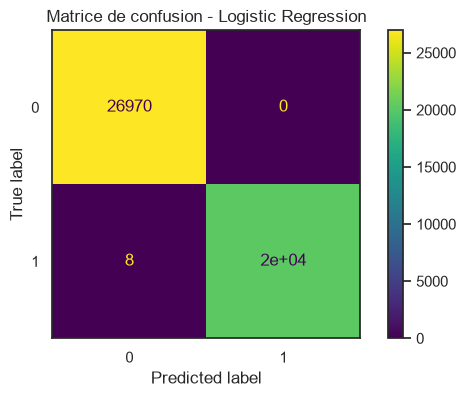

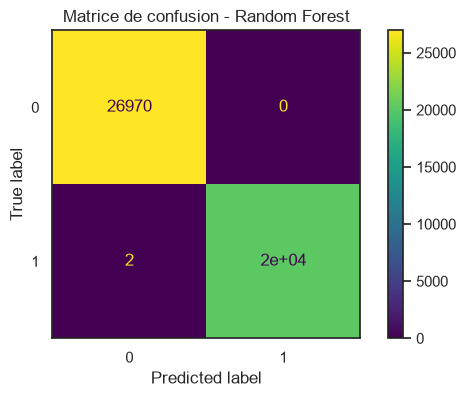

In [13]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot()
    plt.title(f'Matrice de confusion - {name}')
    plt.show()


**Les performances quasi parfaites ne viennent pas d’un modèle exceptionnel ou magique, mais du fait que les données présentent très peu de bruit et des features extrêmement discriminantes. Dans un dataset réel, les résultats seraient beaucoup moins élevés.**

## 10. Réglage d'hyperparamètres (Random Forest)

Pour montrer que nous savons **tuner un modèle**, nous appliquons un `GridSearchCV` simple sur la Random Forest.

Hyperparamètres explorés :
- `n_estimators` : nombre d’arbres ;
- `max_depth` : profondeur maximale des arbres ;
- `min_samples_split` : nombre minimum d’échantillons pour découper un noeud.

Pour réduire le temps de calcul, nous faisons le tuning sur un **sous-échantillon** (20%) du jeu d’entraînement.

In [14]:
# Pipeline RF de base pour le tuning
rf_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Sous-échantillonnage
X_tune = X_train.sample(frac=0.2, random_state=42)
y_tune = y_train.loc[X_tune.index]

param_grid = {
    'model__n_estimators': [150],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [2]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=2,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_tune, y_tune)

print('Meilleurs hyperparamètres :', grid_search.best_params_)
print('Meilleur score (F1, CV) :', grid_search.best_score_)

# Entraînement final sur toutes les données d'entraînement
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)

y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

print('\nPerformances finales sur test :')
print('Accuracy :', accuracy_score(y_test, y_pred_best))
print('Precision :', precision_score(y_test, y_pred_best))
print('Recall :', recall_score(y_test, y_pred_best))
print('F1-score :', f1_score(y_test, y_pred_best))
print('ROC-AUC :', roc_auc_score(y_test, y_proba_best))

Meilleurs hyperparamètres : {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 150}
Meilleur score (F1, CV) : 0.9999382677943083

Performances finales sur test :
Accuracy : 0.9999575902796921
Precision : 1.0
Recall : 0.9999009361533508
F1-score : 0.9999504656231425
ROC-AUC : 0.9999999981634438


On observe que le tuning améliore à peine les performances (qui étaient déjà presque parfaites). Ce n'est pas surprenant compte tenu du **fort pouvoir prédictif des features** et du faible niveau de bruit du dataset.

Le but ici est surtout **méthodologique** : montrer que nous savons identifier des hyperparamètres importants et les ajuster.

## 11. Interprétation : importance des features (Random Forest)

Pour relier les résultats au cas d’usage, nous examinons l’importance des features dans le meilleur modèle Random Forest :
- quelles caractéristiques sont les plus discriminantes ?
- la longueur de l’URL est‑elle vraiment importante ?
- le TLD joue‑t‑il un rôle ?
- nos nouvelles features (`subdomain_count`, `domain_digit_ratio`, etc.) sont‑elles utiles ?

In [15]:
# Récupération des noms de features après préprocessing
best_model = best_rf.named_steps['model']
preprocess_fitted = best_rf.named_steps['preprocess']

# Noms des features catégorielles encodées
ohe = preprocess_fitted.named_transformers_['cat']
cat_feature_names = list(ohe.get_feature_names_out(cat_cols))

# Noms des features numériques + binaires, dans l'ordre du ColumnTransformer.
# Les features créées en section 4 sont déjà incluses dans numeric_cols.
other_feature_names = numeric_cols + binary_cols

all_feature_names = cat_feature_names + other_feature_names

importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]

top_features = [(all_feature_names[i], importances[i]) for i in indices]

fi_df = pd.DataFrame(top_features, columns=['feature', 'importance'])
fi_df

,feature,importance
0,URLSimilarityIndex,0.138878
1,LineOfCode,0.099161
2,NoOfExternalRef,0.098405
3,NoOfSelfRef,0.083551
4,NoOfImage,0.075258
5,HasDescription,0.040349
6,NoOfCSS,0.039738
7,HasSocialNet,0.036199
8,NoOfJS,0.032982
9,IsHTTPS,0.031736


On retrouve en tête des variables :
- `URLSimilarityIndex`,
- des compteurs liés au contenu de la page (`LineOfCode`, `NoOfJS`, `NoOfImage`, `NoOfExternalRef`, ...),
- des indicateurs experts (`HasSocialNet`, `HasCopyrightInfo`, `HasDescription`, `HasSubmitButton`, `IsHTTPS`, ...),
- ainsi que quelques features de structure d’URL (`URLLength`, `URLTitleMatchScore`, ...).

Nos nouvelles features (`subdomain_count`, `url_domain_length_ratio`, `domain_digit_ratio`) n’apparaissent pas forcément dans le Top 20, mais elles restent intéressantes pour l’interprétation et pourraient devenir plus importantes dans d’autres jeux de données.

## 12. Analyse du niveau de bruit du dataset

Pour quantifier le fait que le dataset contient peu de cas ambigus, nous calculons un **score de séparation** :
pour chaque feature numérique, on regarde la différence de moyenne entre classes, normalisée par l’écart‑type global.

In [16]:
print(' Analyse du niveau de bruit du dataset')

separation_scores = {}

for col in numeric_df.columns:
    if col == 'label':
        continue
    mean_0 = df_fe[df_fe['label'] == 0][col].mean()
    mean_1 = df_fe[df_fe['label'] == 1][col].mean()
    std = df_fe[col].std()
    score = abs(mean_0 - mean_1) / (std + 1e-6)
    separation_scores[col] = score

sep_df = pd.DataFrame.from_dict(separation_scores, orient='index', columns=['SeparationScore'])
sep_df = sep_df.sort_values(by='SeparationScore', ascending=False)

sep_df.head(15)

 Analyse du niveau de bruit du dataset


,SeparationScore
URLSimilarityIndex,1.738781
HasSocialNet,1.584973
HasCopyrightInfo,1.502321
HasDescription,1.394954
IsHTTPS,1.231051
DomainTitleMatchScore,1.182091
HasSubmitButton,1.169268
IsResponsive,1.108732
URLTitleMatchScore,1.090164
SpacialCharRatioInURL,1.078243


Les mêmes features que précédemment ressortent avec des scores de séparation élevés (`URLSimilarityIndex`, `HasSocialNet`, `HasCopyrightInfo`, `HasDescription`, `IsHTTPS`, ...).

👉 Cela confirme que le dataset est **peu bruité** : beaucoup d'observations sont faciles à discriminer.
Dans un dataset réel, on s’attendrait à beaucoup plus de chevauchement entre classes.

## 13. Limites du dataset et perspectives

### Limites du dataset

1. **Features très corrélées au label**  
   Des variables comme `URLSimilarityIndex`, `HasSocialNet`, `HasCopyrightInfo`, `HasDescription`, `IsHTTPS` sont quasi des indicateurs de sécurité. Elles capturent déjà fortement le caractère légitime ou frauduleux, ce qui rend la tâche très facile pour les modèles.

2. **Peu de bruit et peu de cas ambigus**  
   Les distributions par classe montrent très peu de chevauchement pour plusieurs features binaires, et les matrices de confusion affichent quasi 0 erreurs. Le dataset ressemble davantage à un **cas d'école** qu'à un trafic web réel.

3. **Convention d'annotation contre-intuitive**  
   Le fichier source annote `1` pour *légitime* et `0` pour *phishing*, à rebours de l'usage
   courant en détection. Une lecture non vérifiée de la documentation inverse toute
   l'interprétation métier sans dégrader aucune métrique : les modèles apprennent aussi bien
   la relation inverse. C'est un rappel utile que de bons scores ne valident jamais la
   compréhension du problème.

4. **Généralisation incertaine**  
   Un modèle entraîné sur ce dataset pourrait se dégrader fortement sur :
   - d'autres sources d'URLs ;
   - des attaquants qui adaptent leurs techniques ;
   - des environnements où certaines features expertes ne sont pas disponibles.

### Que se passerait‑il sur un dataset réel ?

- Les performances seraient **nettement plus basses** (F1 / ROC‑AUC < 1), avec davantage de chevauchement entre classes.
- Il y aurait plus de **faux positifs** (URLs légitimes bloquées) et de **faux négatifs** (phishing non détecté).
- Le **feature engineering** devrait être plus poussé (ex: TF‑IDF sur l’URL, n‑grammes, embeddings de texte, analyse du contenu).
- Des modèles plus sophistiqués (Gradient Boosting, XGBoost, LightGBM, réseaux de neurones pour texte) pourraient être pertinents.
- Il faudrait surveiller la **dérive de concept** : les patterns des attaquants évoluent dans le temps.

### 14. Conclusion

Récapitulatif de la démarche :
- cadrage d'un problème de **classification supervisée binaire** ;
- exploration du dataset et compréhension des features ;
- typologie des variables et **feature engineering léger** ;
- préparation des données via un `ColumnTransformer` + `Pipeline` ;
- comparaison de deux modèles (Régression Logistique, Random Forest) ;
- tuning simple d'hyperparamètres sur la Random Forest ;
- interprétation via l’importance des features et analyse du niveau de bruit ;
- discussion des **limites du dataset** et de la généralisation.

Ce notebook montre que les performances très élevées (≈ 1) ne sont pas le signe d’un modèle extraordinaire, mais plutôt le résultat d’un **dataset très informatif et peu bruité**, contenant plusieurs indicateurs quasi parfaits du label.